In [27]:
import glob 
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [28]:
control=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.spinup/ice/hist/H.a.spinup.cice.h.0038-01.nc')
check=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.rheo_exp/ice/hist/H.a.rheo_exp.cice.h.0040-03.nc')
control=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.rheo_control/ice/hist/H.a.rheo_control.cice.h.0040-03.nc')
check=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.rheo_exp_low_t_test/ice/hist/H.a.rheo_exp_low_t_test.cice.h.0040-03.nc')
control=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.spinup/ice/hist/H.a.spinup.cice.h.0040-03.nc')
check=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.rheo_exp_low_t_latest_middle/ice/hist/H.a.rheo_exp_low_t_latest_middle.cice.h.0040-03.nc')
#check=glob.glob('/glade/derecho/scratch/geraint/H.a.rheo_exp_low_t_latest/run/')
check=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.rheo_exp_LOWER_3p5/ice/hist/H.a.rheo_exp_LOWER_3p5.cice.h.0040-03.nc')
check=glob.glob('/glade/derecho/scratch/geraint/archive/H.a.rheo_exp_low_t_test/ice/hist/H.a.rheo_exp_low_t_test.cice.h.0040-03.nc')
#control=glob.glob('/glade/derecho/scratch/geraint/H.a.rheo_exp_5day_0p01/run/OldHist/H.a.rheo_exp_5day_0p01.cice.h.0037-11.nc')
#control=glob.glob('/glade/derecho/scratch/geraint/H.a.rheo_exp_low_t_test/run/NewerOldHist/H.a.rheo_exp_low_t_test.cice.h.0037-02.nc')
control,check

(['/glade/derecho/scratch/geraint/archive/H.a.spinup/ice/hist/H.a.spinup.cice.h.0040-03.nc'],
 ['/glade/derecho/scratch/geraint/archive/H.a.rheo_exp_low_t_test/ice/hist/H.a.rheo_exp_low_t_test.cice.h.0040-03.nc'])

In [29]:
ds_c = xr.open_mfdataset(control, combine='by_coords')
ds_a = xr.open_mfdataset(check, combine='by_coords')

In [30]:
ds_c_hi=ds_c.hi.mean(dim='time')
ds_a_hi=ds_a.hi.mean(dim='time')

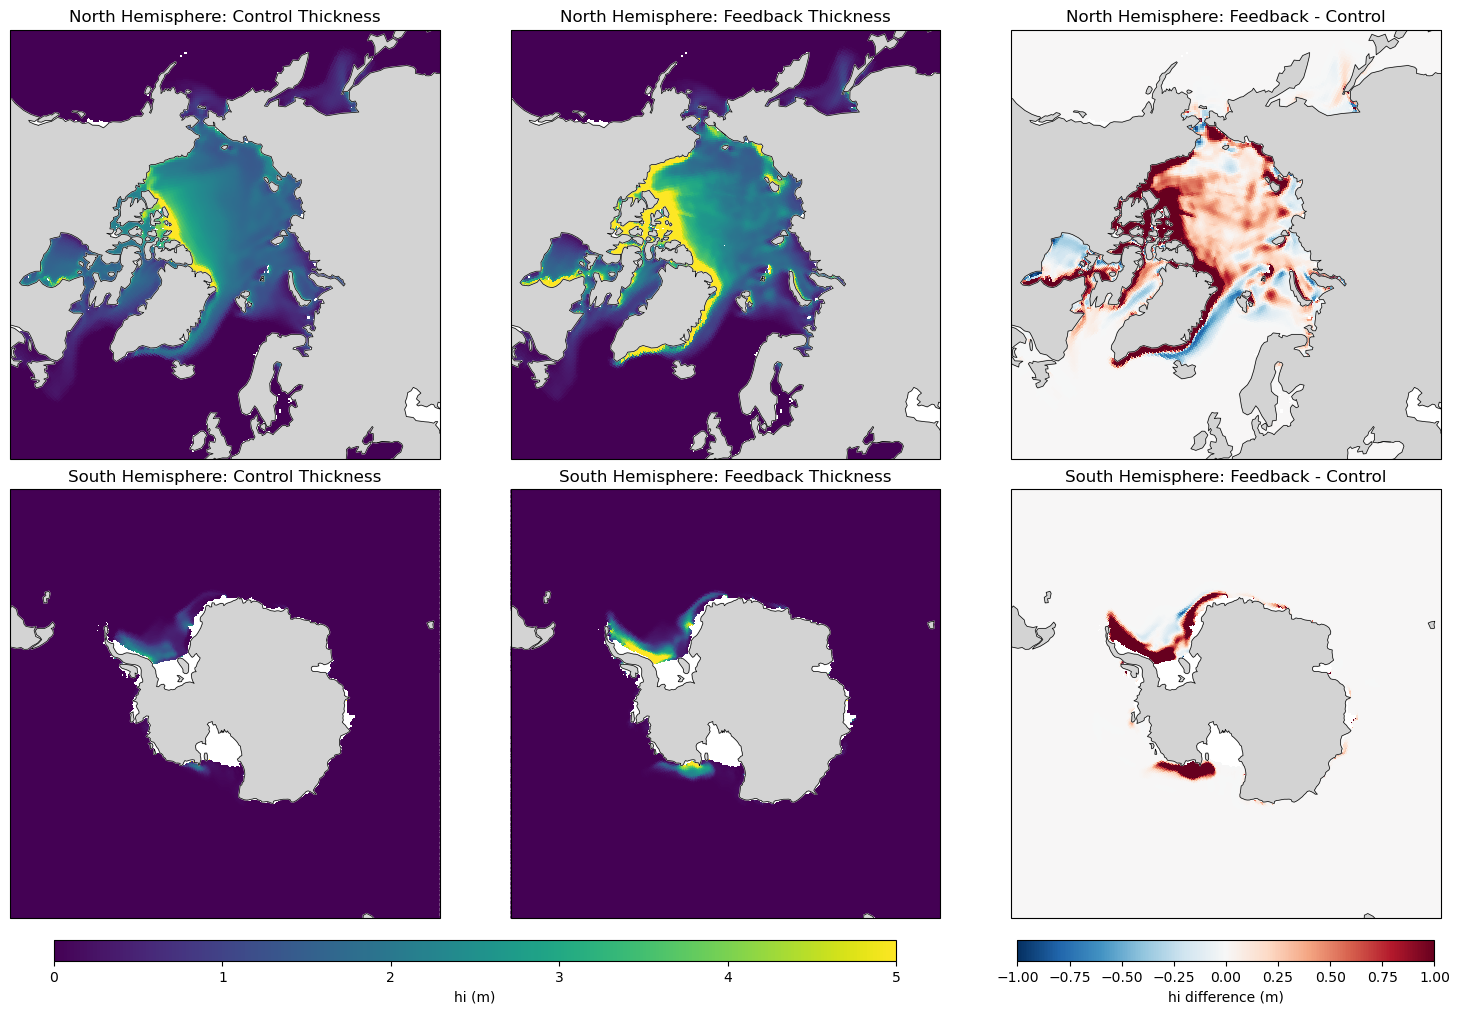

In [31]:
import numpy as np

import cartopy.feature as cfeature

# Use hi_d if available, otherwise hi
hi_var = "hi_d" if "hi_d" in ds_c.data_vars else "hi"

hi_c = ds_c[hi_var].squeeze(drop=True)
hi_a = ds_a[hi_var].squeeze(drop=True)
hi_diff = hi_a - hi_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels (control/experiment) scale
vmin_main = 0.0
vmax_main = 5
if not np.isfinite(vmax_main) or vmax_main <= 0:
    vmax_main = 1.0

# Difference panel scale (symmetric)
vmax_diff = 1
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 0.1

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(hi_c, "Control Thickness"), (hi_a, "Feedback Thickness"), (hi_diff, "Feedback - Control")],
    [(hi_c, "Control Thickness"), (hi_a, "Feedback Thickness"), (hi_diff, "Feedback - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main, vmax=vmax_main,
                shading="auto",
            )
            m_main = m
        else:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-1, vmax=1,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

# Colorbar for first two columns
fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.02, aspect=40,
    label=f"{hi_var} (m)",
)

# Colorbar for difference column
fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.02, aspect=20,
    label=f"{hi_var} difference (m)",
)

plt.show()

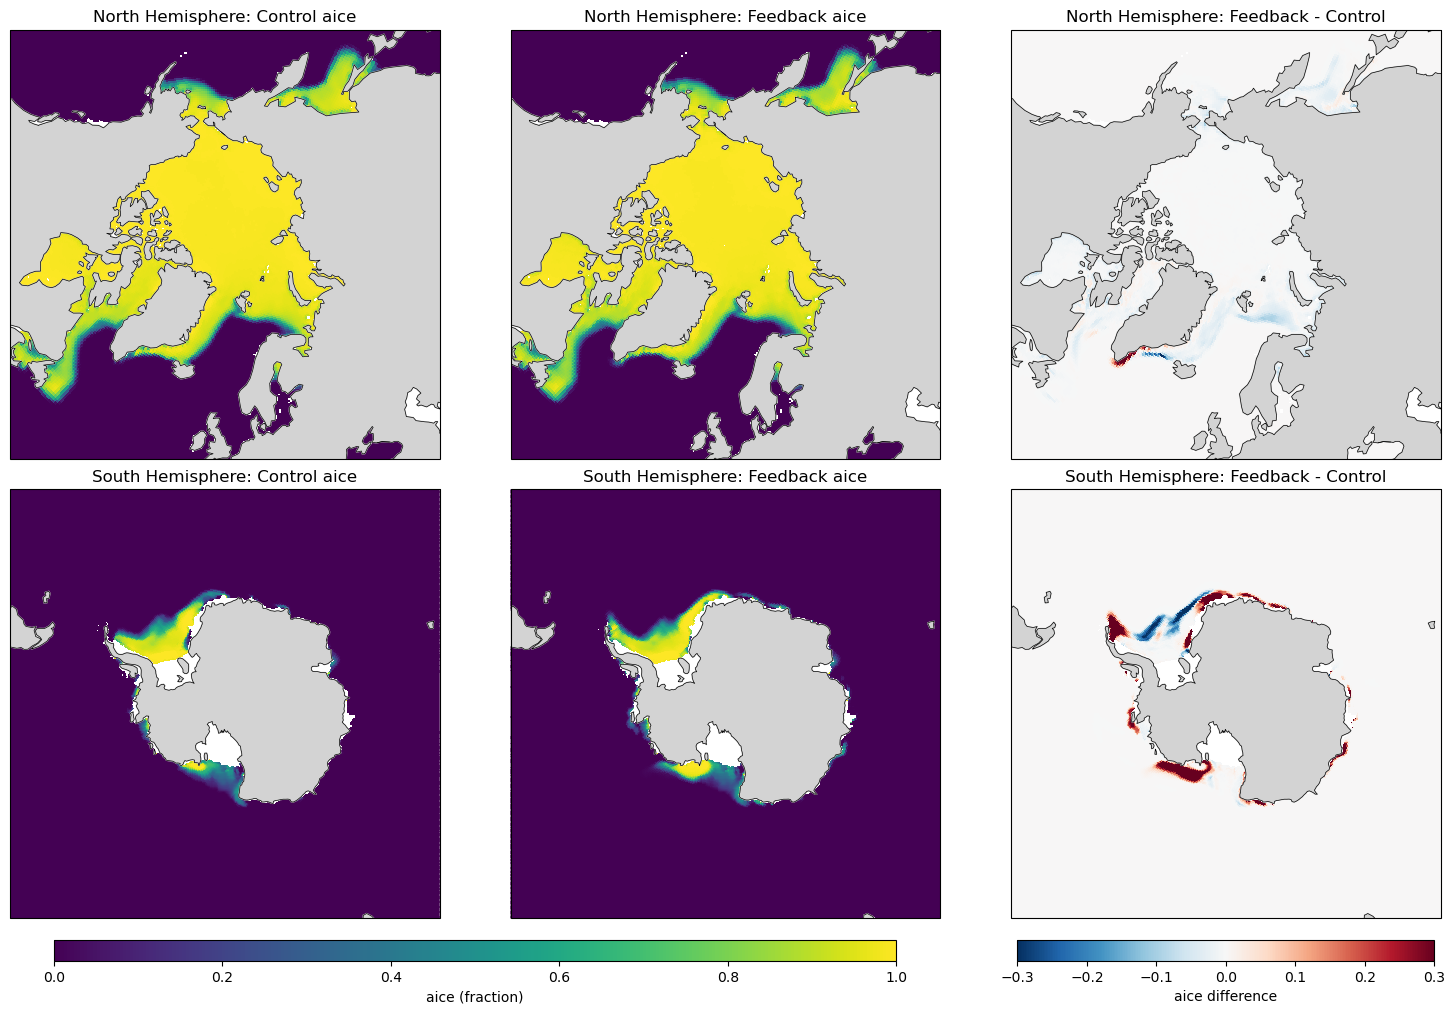

In [32]:
import numpy as np

import cartopy.feature as cfeature

# Use aice_d if available, otherwise aice
aice_var = "aice_d" if "aice_d" in ds_c.data_vars else "aice"

aice_c = ds_c[aice_var].squeeze(drop=True)
aice_a = ds_a[aice_var].squeeze(drop=True)
aice_diff = aice_a - aice_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels (control/experiment) scale
vmin_main = 0.0
vmax_main = 1.0
if not np.isfinite(vmax_main) or vmax_main <= 0:
    vmax_main = 1.0

# Difference panel scale (symmetric)
vmax_diff = 0.3
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 0.1

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(aice_c, "Control aice"), (aice_a, "Feedback aice"), (aice_diff, "Feedback - Control")],
    [(aice_c, "Control aice"), (aice_a, "Feedback aice"), (aice_diff, "Feedback - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main,
                vmax=vmax_main,
                shading="auto",
            )
            m_main = m
        else:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_diff,
                vmax=vmax_diff,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

# Colorbar for first two columns
fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.02,
    aspect=40,
    label=f"{aice_var} (fraction)",
)

# Colorbar for difference column
fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.02,
    aspect=20,
    label=f"{aice_var} difference",
)

plt.show()

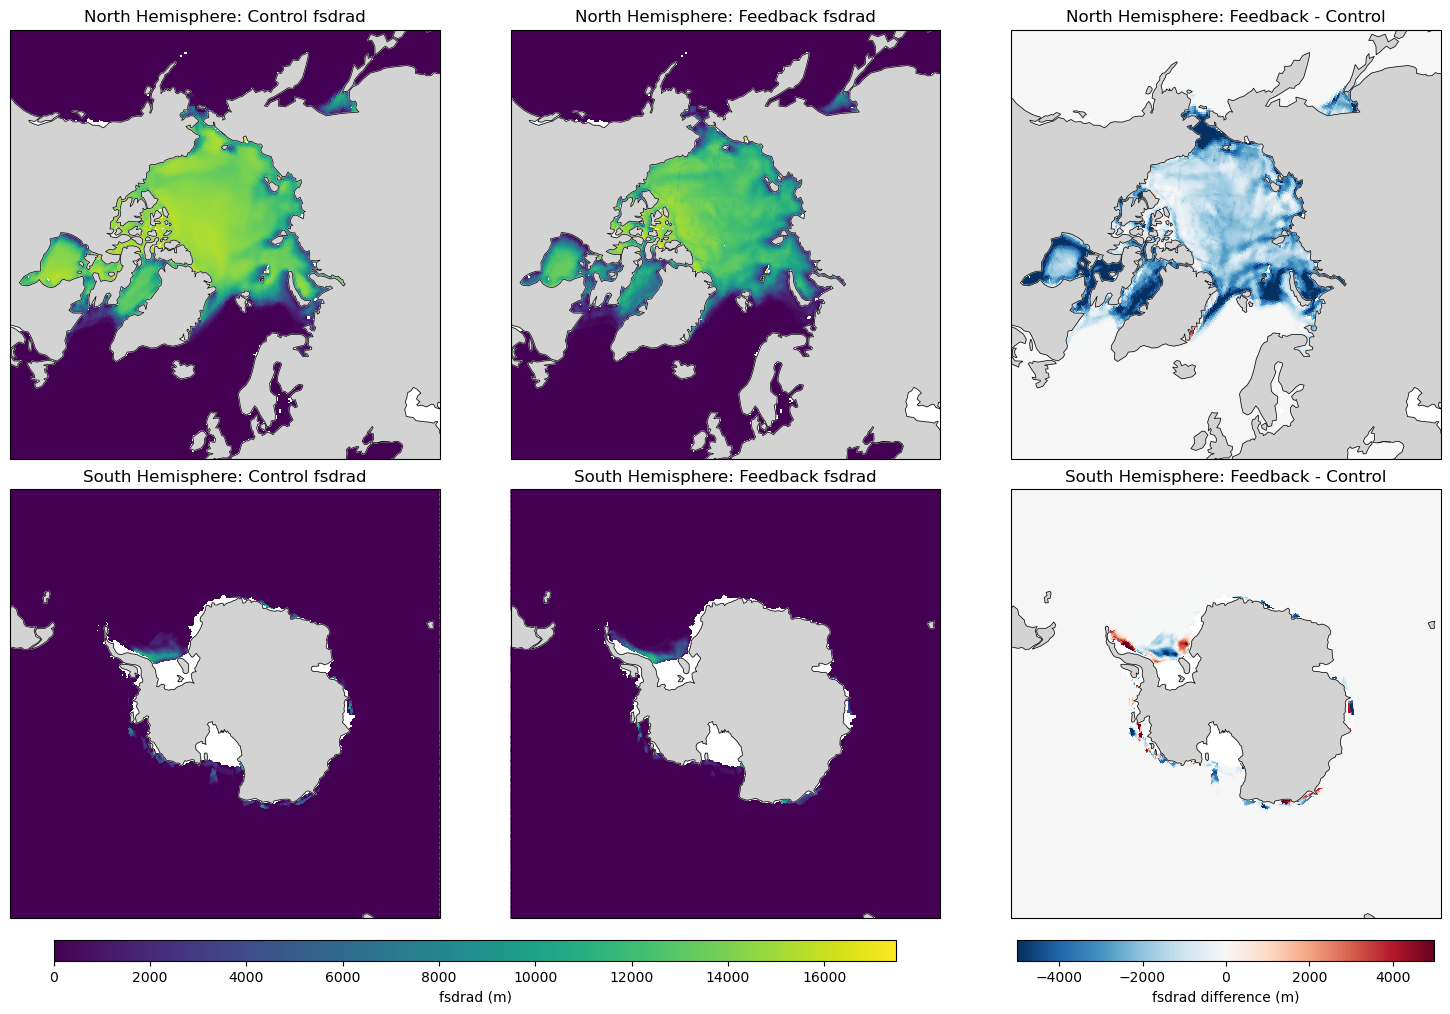

In [33]:
# Use fsdrad_d if available, otherwise fsdrad
fsdrad_var = "fsdrad_d" if "fsdrad_d" in ds_c.data_vars else "fsdrad"

fsdrad_c = ds_c[fsdrad_var].squeeze(drop=True)
fsdrad_a = ds_a[fsdrad_var].squeeze(drop=True)
fsdrad_diff = fsdrad_a - fsdrad_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels (control/experiment) scale
vmin_main = 0.0
vmax_main = 17500.0
if not np.isfinite(vmax_main) or vmax_main <= 0:
	vmax_main = 1.0

# Difference panel scale (symmetric; robust)
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(fsdrad_diff.compute()), 99)))
if not np.isfinite(vmax_diff) or vmax_diff == 0:
	vmax_diff = 1.0

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
	[(fsdrad_c, "Control fsdrad"), (fsdrad_a, "Feedback fsdrad"), (fsdrad_diff, "Feedback - Control")],
	[(fsdrad_c, "Control fsdrad"), (fsdrad_a, "Feedback fsdrad"), (fsdrad_diff, "Feedback - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
	zip(projs, masks, extents, row_names, row_fields)
):
	for c, (field, title) in enumerate(plot_fields):
		ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
		axes[r, c] = ax

		if c < 2:
			m = ax.pcolormesh(
				lon, lat, field.where(mask),
				transform=ccrs.PlateCarree(),
				cmap="viridis",
				vmin=vmin_main,
				vmax=vmax_main,
				shading="auto",
			)
			m_main = m
		else:
			m = ax.pcolormesh(
				lon, lat, field.where(mask),
				transform=ccrs.PlateCarree(),
				cmap="RdBu_r",
				vmin=-vmax_diff,
				vmax=vmax_diff,
				shading="auto",
			)
			m_diff = m

		ax.coastlines(linewidth=0.5)
		ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
		ax.set_extent(extent, crs=ccrs.PlateCarree())
		ax.set_title(f"{row_name}: {title}")

fig.colorbar(
	m_main,
	ax=axes[:, :2].ravel().tolist(),
	orientation="horizontal",
	shrink=0.85,
	pad=0.02,
	aspect=40,
	label=f"{fsdrad_var} (m)",
)

fig.colorbar(
	m_diff,
	ax=axes[:, 2].ravel().tolist(),
	orientation="horizontal",
	shrink=0.85,
	pad=0.02,
	aspect=20,
	label=f"{fsdrad_var} difference (m)",
)

plt.show()

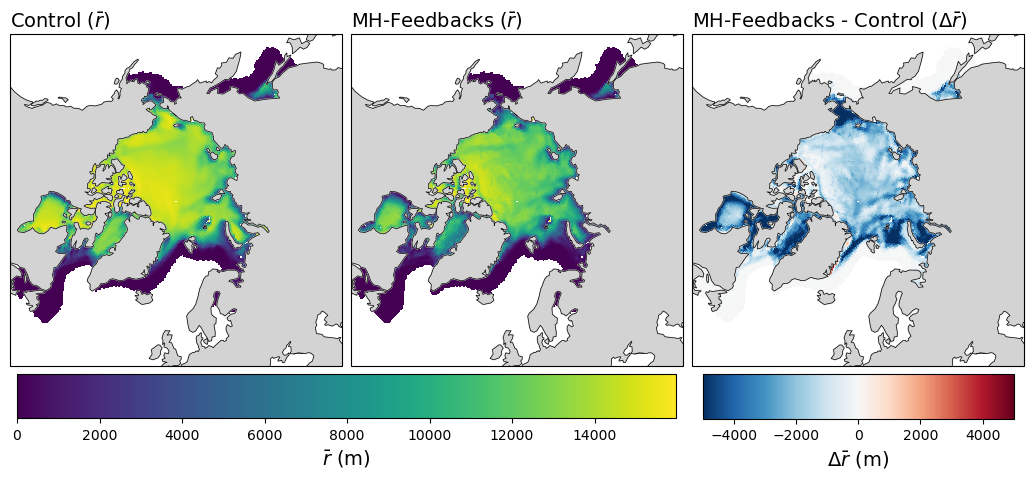

In [34]:
# Mask fsdrad where aice < 0.15 (North hemisphere only)
north_mask = lat >= 0
mask_c = north_mask & (aice_c >= 0.15)
mask_a = north_mask & (aice_a >= 0.15)
mask_diff = north_mask & ((aice_c >= 0.15) | (aice_a >= 0.15))

fsdrad_c_plot = fsdrad_c.where(mask_c)
fsdrad_a_plot = fsdrad_a.where(mask_a)
fsdrad_diff_plot = fsdrad_diff.where(mask_diff)

# Robust linear color bounds
vals_c = fsdrad_c_plot.compute().values.ravel()
vals_a = fsdrad_a_plot.compute().values.ravel()
vals = np.concatenate([vals_c, vals_a])
vals = vals[np.isfinite(vals)]
vmin_main = 0.0
vmax_main = float(np.nanpercentile(vals, 99)) if vals.size else 1.0
if vmax_main <= vmin_main:
    vmax_main = vmin_main + 1.0

fd_vals = fsdrad_diff_plot.compute().values.ravel()
fd_vals = fd_vals[np.isfinite(fd_vals)]
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(fd_vals), 99))) if fd_vals.size else 1.0
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 1.0

# Plot North-hemisphere linear-scale panels
fig = plt.figure(figsize=(15, 5))
axes = np.empty((1, 3), dtype=object)

# Layout controls
wspace = -0.55       # horizontal spacing between panels (try -0.1 to 0.1)
cbar_pad = 0.02     # gap between maps and colorbars
cbar_shrink = 0.6   # colorbar length (lower = shorter)
cbar_aspect = 15    # colorbar thickness ratio (lower = thicker)

proj = ccrs.NorthPolarStereo()
extent = [-180, 180, 50, 90]

plot_fields = [
    (fsdrad_c_plot, r"Control ($\bar{r}$)"),
    (fsdrad_a_plot, r"MH-Feedbacks ($\bar{r}$)"),
    (fsdrad_diff_plot, r"MH-Feedbacks - Control ($\Delta \bar{r}$)"),
]

m_main = None
m_diff = None

for c_idx, (field, title) in enumerate(plot_fields):
    ax = fig.add_subplot(1, 3, c_idx + 1, projection=proj)
    axes[0, c_idx] = ax

    if c_idx < 2:
        m = ax.pcolormesh(
            lon, lat, field,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            vmin=0,
            vmax=vmax_main,
            shading="auto",
        )
        m_main = m
    else:
        m = ax.pcolormesh(
            lon, lat, field,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=-5000,
            vmax=5000,
            shading="auto",
        )
        m_diff = m

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(f"{title}", loc="left", fontsize=14)

fig.subplots_adjust(wspace=wspace, left=0.02, right=0.98, top=0.95, bottom=0.15)

cb1 = fig.colorbar(
    m_main,
    ax=axes[0, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=cbar_shrink,
    pad=cbar_pad,
    aspect=cbar_aspect,
    label=r"$\bar{r}$ (m)",
)
cb1.set_label(r"$\bar{r}$ (m)", fontsize=14)
cb1.ax.tick_params(labelsize=10)

cb2 = fig.colorbar(
    m_diff,
    ax=axes[0, 2],
    orientation="horizontal",
    shrink=cbar_shrink - 0.19,
    pad=cbar_pad,
    aspect=cbar_aspect - 8,
    label=r"$\Delta \bar{r}$ (m)",
)
cb2.set_label(r"$\Delta \bar{r}$ (m)", fontsize=14)
cb2.ax.tick_params(labelsize=10)

plt.show()

/glade/derecho/scratch/geraint/tmp/ipykernel_75634/3193309744.py:37: RuntimeWarning: divide by zero encountered in divide
  smoothed = np.where(den > 0, num / den, np.nan)
/glade/derecho/scratch/geraint/tmp/ipykernel_75634/3193309744.py:37: RuntimeWarning: invalid value encountered in divide
  smoothed = np.where(den > 0, num / den, np.nan)
/glade/derecho/scratch/geraint/tmp/ipykernel_75634/3193309744.py:37: RuntimeWarning: divide by zero encountered in divide
  smoothed = np.where(den > 0, num / den, np.nan)
/glade/derecho/scratch/geraint/tmp/ipykernel_75634/3193309744.py:37: RuntimeWarning: invalid value encountered in divide
  smoothed = np.where(den > 0, num / den, np.nan)


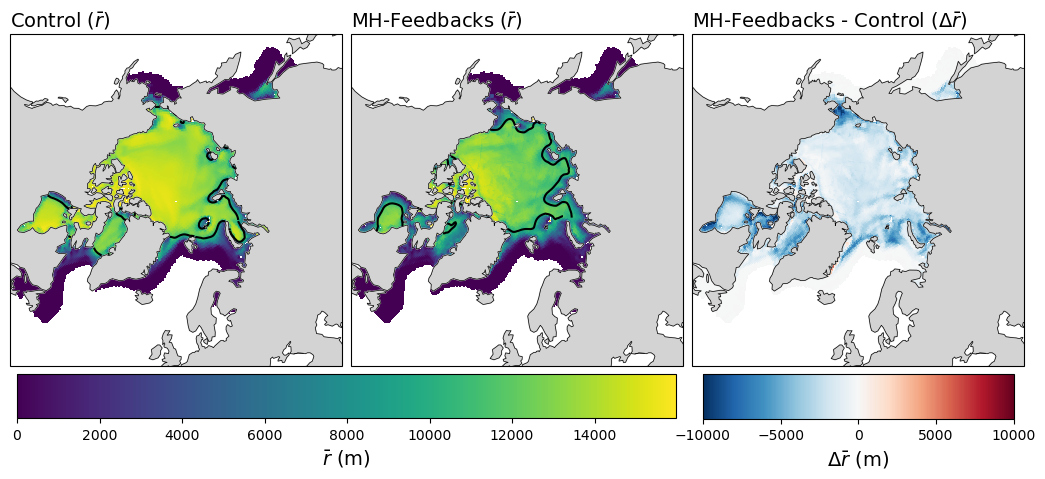

In [35]:
from scipy.ndimage import uniform_filter

# Mask fsdrad where aice < 0.15 (North hemisphere only)
north_mask = lat >= 0
mask_c = north_mask & (aice_c >= 0.15)
mask_a = north_mask & (aice_a >= 0.15)
mask_diff = north_mask & ((aice_c >= 0.15) | (aice_a >= 0.15))

fsdrad_c_plot = fsdrad_c.where(mask_c)
fsdrad_a_plot = fsdrad_a.where(mask_a)
fsdrad_diff_plot = fsdrad_diff.where(mask_diff)

# Robust linear color bounds
vals_c = fsdrad_c_plot.compute().values.ravel()
vals_a = fsdrad_a_plot.compute().values.ravel()
vals = np.concatenate([vals_c, vals_a])
vals = vals[np.isfinite(vals)]
vmin_main = 0.0
vmax_main = float(np.nanpercentile(vals, 99)) if vals.size else 1.0
if vmax_main <= vmin_main:
    vmax_main = vmin_main + 1.0

fd_vals = fsdrad_diff_plot.compute().values.ravel()
fd_vals = fd_vals[np.isfinite(fd_vals)]
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(fd_vals), 99))) if fd_vals.size else 1.0
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 1.0

def smooth_for_contour(field_da, win=7):
    """NaN-aware uniform smoothing with coarsened grid for contours."""
    arr = field_da.compute().values.astype(float)
    nan_mask = ~np.isfinite(arr)
    filled = np.where(nan_mask, 0.0, arr)
    weights = (~nan_mask).astype(float)
    num = uniform_filter(filled, size=win, mode="nearest")
    den = uniform_filter(weights, size=win, mode="nearest")
    smoothed = np.where(den > 0, num / den, np.nan)
    smoothed[nan_mask] = np.nan
    return smoothed

# Plot North-hemisphere linear-scale panels
fig = plt.figure(figsize=(15, 5))
axes = np.empty((1, 3), dtype=object)

# Layout controls
wspace = -0.55
cbar_pad = 0.02
cbar_shrink = 0.6
cbar_aspect = 15

proj = ccrs.NorthPolarStereo()
extent = [-180, 180, 50, 90]

# Project lon/lat -> NorthPolarStereo map coords ONCE.
# Contouring in projected space (no transform=) avoids cartopy re-projecting
# the contour path across the ±180 seam, which is what draws the giant chords.
pts = proj.transform_points(ccrs.PlateCarree(), np.asarray(lon), np.asarray(lat))
x_proj = pts[..., 0]
y_proj = pts[..., 1]
# defensive: any non-finite projected coord -> NaN so contour skips that quad
x_proj = np.where(np.isfinite(x_proj), x_proj, np.nan)
y_proj = np.where(np.isfinite(y_proj), y_proj, np.nan)

plot_fields = [
    (fsdrad_c_plot, r"Control ($\bar{r}$)"),
    (fsdrad_a_plot, r"MH-Feedbacks ($\bar{r}$)"),
    (fsdrad_diff_plot, r"MH-Feedbacks - Control ($\Delta \bar{r}$)"),
]

m_main = None
m_diff = None

for c_idx, (field, title) in enumerate(plot_fields):
    ax = fig.add_subplot(1, 3, c_idx + 1, projection=proj)
    axes[0, c_idx] = ax

    if c_idx < 2:
        m = ax.pcolormesh(
            lon, lat, field,
            transform=ccrs.PlateCarree(),   # pcolormesh draws per-quad, no seam chords
            cmap="viridis",
            vmin=0,
            vmax=vmax_main,
            shading="auto",
        )
        m_main = m

        # Add 10km contour using PROJECTED coords (win=9 ~4 gridcells between lines)
        smoothed = smooth_for_contour(field, win=9)
        cs = ax.contour(
            x_proj, y_proj, smoothed,       # projected coords, not lon/lat
            levels=[10000],
            colors="k",
            linewidths=1.5,
            # NOTE: no transform= -> drawn directly in projected data coords
        )
        ax.clabel(cs, fmt={10000: "10 km"}, fontsize=8, inline=True)
    else:
        m = ax.pcolormesh(
            lon, lat, field,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=-10000,
            vmax=10000,
            shading="auto",
        )
        m_diff = m

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(f"{title}", loc="left", fontsize=14)

fig.subplots_adjust(wspace=wspace, left=0.02, right=0.98, top=0.95, bottom=0.15)

cb1 = fig.colorbar(
    m_main,
    ax=axes[0, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=cbar_shrink,
    pad=cbar_pad,
    aspect=cbar_aspect,
    label=r"$\bar{r}$ (m)",
)
cb1.set_label(r"$\bar{r}$ (m)", fontsize=14)
cb1.ax.tick_params(labelsize=10)

cb2 = fig.colorbar(
    m_diff,
    ax=axes[0, 2],
    orientation="horizontal",
    shrink=cbar_shrink - 0.19,
    pad=cbar_pad,
    aspect=cbar_aspect - 8,
    label=r"$\Delta \bar{r}$ (m)",
)
cb2.set_label(r"$\Delta \bar{r}$ (m)", fontsize=14)
cb2.ax.tick_params(labelsize=10)

plt.show()

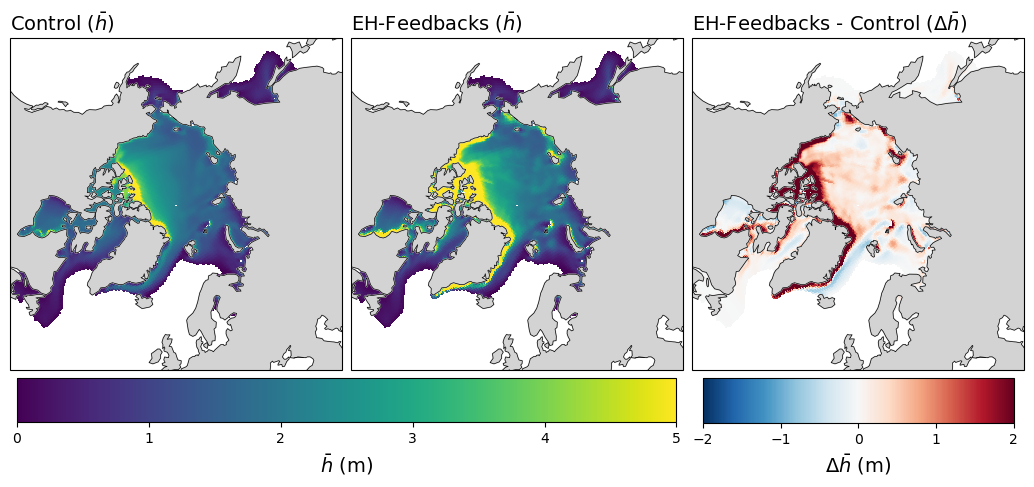

In [36]:
# Mask hi where aice < 0.15 (North hemisphere only)
north_mask = lat >= 0
mask_c = north_mask & (aice_c >= 0.15)
mask_a = north_mask & (aice_a >= 0.15)
mask_diff = north_mask & ((aice_c >= 0.15) | (aice_a >= 0.15))

hi_c_plot = hi_c.where(mask_c)
hi_a_plot = hi_a.where(mask_a)
hi_diff_plot = hi_diff.where(mask_diff)

# Robust linear color bounds
vals_c = hi_c_plot.compute().values.ravel()
vals_a = hi_a_plot.compute().values.ravel()
vals = np.concatenate([vals_c, vals_a])
vals = vals[np.isfinite(vals)]
vmin_main = 0.0
vmax_main = float(np.nanpercentile(vals, 99)) if vals.size else 1.0
if vmax_main <= vmin_main:
    vmax_main = vmin_main + 1.0

hi_vals = hi_diff_plot.compute().values.ravel()
hi_vals = hi_vals[np.isfinite(hi_vals)]
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(hi_vals), 99))) if hi_vals.size else 1.0
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 1.0

# Plot North-hemisphere linear-scale panels
fig = plt.figure(figsize=(15, 5))
axes = np.empty((1, 3), dtype=object)

# Layout controls
wspace = -0.55       # horizontal spacing between panels (try -0.1 to 0.1)
cbar_pad = 0.02     # gap between maps and colorbars
cbar_shrink = 0.6   # colorbar length (lower = shorter)
cbar_aspect = 15    # colorbar thickness ratio (lower = thicker)

proj = ccrs.NorthPolarStereo()
extent = [-180, 180, 50, 90]

plot_fields = [
    (hi_c_plot, r"Control ($\bar{h}$)"),
    (hi_a_plot, r"EH-Feedbacks ($\bar{h}$)"),
    (hi_diff_plot, r"EH-Feedbacks - Control ($\Delta \bar{h}$)"),
]

m_main = None
m_diff = None

for c_idx, (field, title) in enumerate(plot_fields):
    ax = fig.add_subplot(1, 3, c_idx + 1, projection=proj)
    axes[0, c_idx] = ax

    if c_idx < 2:
        m = ax.pcolormesh(
            lon, lat, field,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            vmin=vmin_main,
            vmax=5,
            shading="auto",
        )
        m_main = m
    else:
        m = ax.pcolormesh(
            lon, lat, field,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=-2,
            vmax=2,
            shading="auto",
        )
        m_diff = m

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(f"{title}", loc="left", fontsize=14)

fig.subplots_adjust(wspace=wspace, left=0.02, right=0.98, top=0.95, bottom=0.15)

cb1 = fig.colorbar(
    m_main,
    ax=axes[0, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=cbar_shrink,
    pad=cbar_pad,
    aspect=cbar_aspect,
    label=r"$\bar{h}$ (m)",
)
cb1.set_label(r"$\bar{h}$ (m)", fontsize=14)
cb1.ax.tick_params(labelsize=10)

cb2 = fig.colorbar(
    m_diff,
    ax=axes[0, 2],
    orientation="horizontal",
    shrink=cbar_shrink - 0.19,
    pad=cbar_pad,
    aspect=cbar_aspect - 8,
    label=r"$\Delta \bar{h}$ (m)",
)
cb2.set_label(r"$\Delta \bar{h}$ (m)", fontsize=14)
cb2.ax.tick_params(labelsize=10)

plt.show()

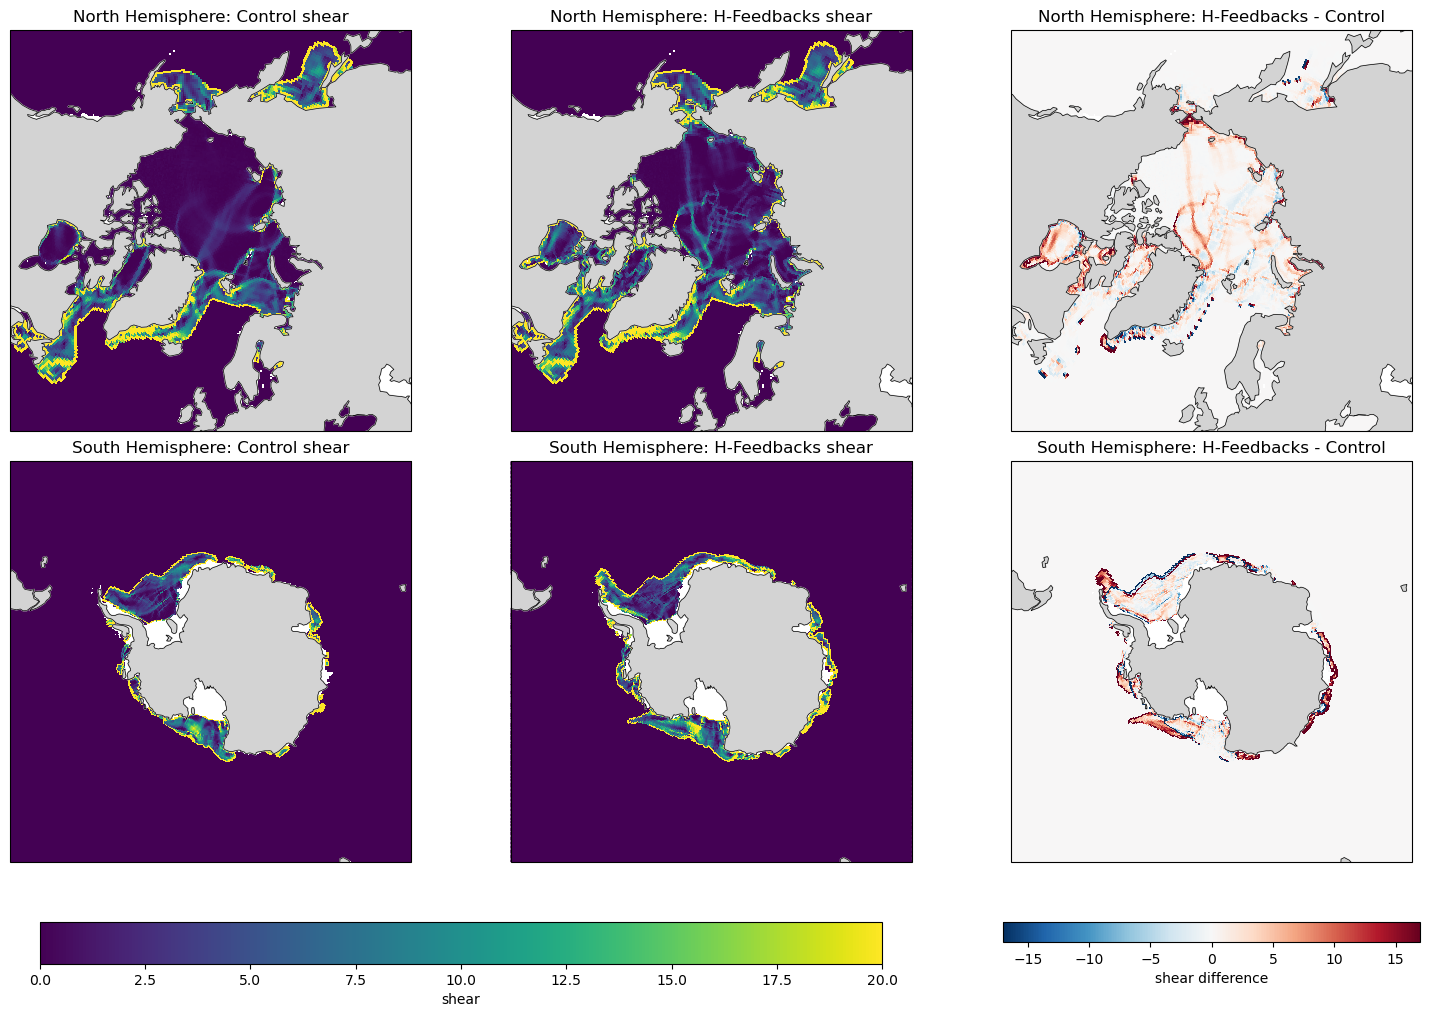

In [37]:
# Use shear_d if available, otherwise shear
shear_var = "shear_d" if "shear_d" in ds_c.data_vars else "shear"

shear_c = ds_c[shear_var].squeeze(drop=True)
shear_a = ds_a[shear_var].squeeze(drop=True)
shear_diff = shear_a - shear_c

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels scale
vmin_main = 0.0
vmax_main = 20
if not np.isfinite(vmax_main) or vmax_main <= 0:
    vmax_main = 1.0

# Difference panel scale (symmetric, robust)
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(shear_diff.compute()), 99)))
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 0.1

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(shear_c, "Control shear"), (shear_a, "H-Feedbacks shear"), (shear_diff, "H-Feedbacks - Control")],
    [(shear_c, "Control shear"), (shear_a, "H-Feedbacks shear"), (shear_diff, "H-Feedbacks - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main, vmax=vmax_main,
                shading="auto",
            )
            m_main = m
        else:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_diff, vmax=vmax_diff,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{shear_var}",
)

fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{shear_var} difference",
)

plt.show()

In [38]:
./

SyntaxError: invalid syntax (3428464911.py, line 1)

In [ ]:
# Average ice thickness (area-weighted if tarea is available)
# Excludes NaN and zero-thickness cells from the mean.

hi_var = "hi_d" if "hi_d" in ds_c.data_vars else "hi"
hi_c = ds_c[hi_var].squeeze(drop=True)
hi_a = ds_a[hi_var].squeeze(drop=True)
hi_diff = hi_a - hi_c

north_mask = ds_c.TLAT >= 0
south_mask = ds_c.TLAT < 0

weights = ds_c["tarea"] if "tarea" in ds_c.data_vars else None

def mean_thickness(field, mask=None):
    # Exclude NaN and zero values
    valid = field.notnull() & (field != 0)
    if mask is not None:
        valid = valid & mask
    f = field.where(valid)
    if weights is not None:
        w = weights.where(valid).fillna(0)
        return float(f.weighted(w).mean(dim=("nj", "ni")).compute())
    return float(f.mean(dim=("nj", "ni"), skipna=True).compute())

print(f"{hi_var} global mean (control):    {mean_thickness(hi_c):.4f} m")
print(f"{hi_var} global mean (experiment): {mean_thickness(hi_a):.4f} m")
print(f"{hi_var} global mean (A-Control):  {mean_thickness(hi_diff):+.4f} m")
print("---")
print(f"{hi_var} NH mean (control):        {mean_thickness(hi_c, north_mask):.4f} m")
print(f"{hi_var} NH mean (experiment):     {mean_thickness(hi_a, north_mask):.4f} m")
print(f"{hi_var} NH mean (A-Control):      {mean_thickness(hi_diff, north_mask):+.4f} m")
print("---")
print(f"{hi_var} SH mean (control):        {mean_thickness(hi_c, south_mask):.4f} m")
print(f"{hi_var} SH mean (experiment):     {mean_thickness(hi_a, south_mask):.4f} m")
print(f"{hi_var} SH mean (A-Control):      {mean_thickness(hi_diff, south_mask):+.4f} m")

hi global mean (control):    1.1041 m
hi global mean (experiment): 2.6544 m
hi global mean (A-Control):  +1.4931 m
---
hi NH mean (control):        1.4390 m
hi NH mean (experiment):     3.1171 m
hi NH mean (A-Control):      +1.6727 m
---
hi SH mean (control):        0.1924 m
hi SH mean (experiment):     1.4510 m
hi SH mean (A-Control):      +1.0901 m


In [ ]:
# Use aice_d if available, otherwise aice
aice_var = "aice_d" if "aice_d" in ds_c.data_vars else "aice"

aice_c = ds_c[aice_var].squeeze(drop=True)
aice_a = ds_a[aice_var].squeeze(drop=True)
aice_diff = aice_a - aice_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels scale
vmin_main = 0.0
vmax_main = 1.0

# Difference panel scale (symmetric, robust)
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(aice_diff.compute()), 99)))
if not np.isfinite(vmax_diff) or vmax_diff == 0:
	vmax_diff = 0.1

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
	[(aice_c, "Control aice"), (aice_a, "A aice"), (aice_diff, "A - Control")],
	[(aice_c, "Control aice"), (aice_a, "A aice"), (aice_diff, "A - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
	zip(projs, masks, extents, row_names, row_fields)
):
	for c, (field, title) in enumerate(plot_fields):
		ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
		axes[r, c] = ax

		if c < 2:
			m = ax.pcolormesh(
				lon, lat, field.where(mask),
				transform=ccrs.PlateCarree(),
				cmap="viridis",
				vmin=vmin_main, vmax=vmax_main,
				shading="auto",
			)
			m_main = m
		else:
			m = ax.pcolormesh(
				lon, lat, field.where(mask),
				transform=ccrs.PlateCarree(),
				cmap="RdBu_r",
				vmin=-vmax_diff, vmax=vmax_diff,
				shading="auto",
			)
			m_diff = m

		ax.coastlines(linewidth=0.5)
		ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
		ax.set_extent(extent, crs=ccrs.PlateCarree())
		ax.set_title(f"{row_name}: {title}")

fig.colorbar(
	m_main,
	ax=axes[:, :2].ravel().tolist(),
	orientation="horizontal",
	shrink=0.85,
	pad=0.06,
	label=f"{aice_var}",
)

fig.colorbar(
	m_diff,
	ax=axes[:, 2].ravel().tolist(),
	orientation="horizontal",
	shrink=0.85,
	pad=0.06,
	label=f"{aice_var} difference",
)

plt.show()

In [ ]:
./

In [ ]:
aicen_var = "aicen"
cat_dim = "n" if "n" in ds_c[aicen_var].dims else "nc"

aicen_c = ds_c[aicen_var].isel({cat_dim: 2}).squeeze(drop=True)
aicen_a = ds_a[aicen_var].isel({cat_dim: 2}).squeeze(drop=True)
aicen_diff = aicen_a - aicen_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels scale: bounded 0 to 1
vmin_main = 0.0
vmax_main = 1.0

# Difference panel scale (symmetric, robust)
vmax_diff = 0.3
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 0.1

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 60, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(aicen_c, "Control aicen"), (aicen_a, "A aicen"), (aicen_diff, "A - Control")],
    [(aicen_c, "Control aicen"), (aicen_a, "A aicen"), (aicen_diff, "A - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main, vmax=vmax_main,
                shading="auto",
            )
            m_main = m
        else:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_diff, vmax=vmax_diff,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{aicen_var} (category n=4)",
)

fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{aicen_var} difference (category n=4)",
)

plt.show()

In [ ]:
import numpy as np

import cartopy.feature as cfeature

# Use shear_d if available, otherwise shear
shear_var = "shear_d" if "shear_d" in ds_c.data_vars else "shear"

shear_c = ds_c[shear_var].squeeze(drop=True)
shear_a = ds_a[shear_var].squeeze(drop=True)
shear_diff = shear_a - shear_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels (control/experiment) scale
vmin_main = 0.0
vmax_main = 20
if not np.isfinite(vmax_main) or vmax_main <= 0:
    vmax_main = 1.0

# Difference panel scale (symmetric)
vmax_diff = 5
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 0.1

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(shear_c, "Control shear"), (shear_a, "A shear"), (shear_diff, "A - Control")],
    [(shear_c, "Control shear"), (shear_a, "A shear"), (shear_diff, "A - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main, vmax=vmax_main,
                shading="auto",
            )
            m_main = m
        else:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_diff, vmax=vmax_diff,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{shear_var}",
)

fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{shear_var} difference",
)

plt.show()

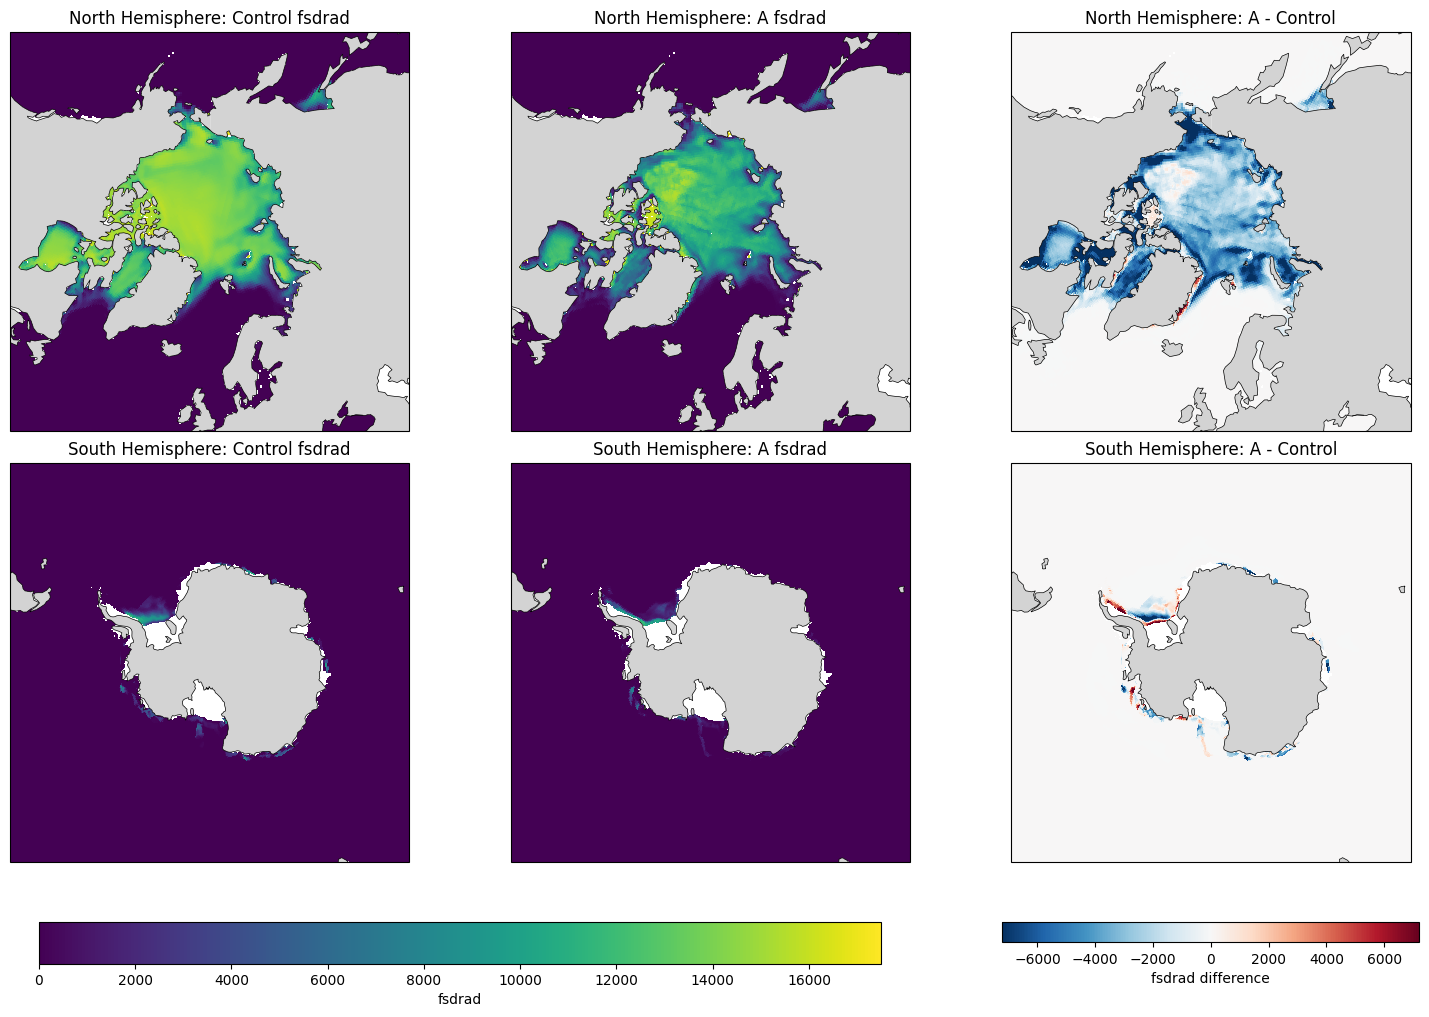

In [ ]:
# Use fsdrad_d if available, otherwise fsdrad
fsdrad_var = "fsdrad_d" if "fsdrad_d" in ds_c.data_vars else "fsdrad"

fsdrad_c = ds_c[fsdrad_var].squeeze(drop=True)
fsdrad_a = ds_a[fsdrad_var].squeeze(drop=True)
fsdrad_diff = fsdrad_a - fsdrad_c  # experiment - control

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180

north_mask = lat >= 0
south_mask = lat < 0

# Main panels (control/experiment) scale
vmin_main = 0.0
vmax_main = 17500
if not np.isfinite(vmax_main) or vmax_main <= 0:
    vmax_main = 1.0

# Difference panel scale (symmetric; robust)
vmax_diff = float(np.ceil(np.nanpercentile(np.abs(fsdrad_diff.compute()), 99)))
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 1.0

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(fsdrad_c, "Control fsdrad"), (fsdrad_a, "A fsdrad"), (fsdrad_diff, "A - Control")],
    [(fsdrad_c, "Control fsdrad"), (fsdrad_a, "A fsdrad"), (fsdrad_diff, "A - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main, vmax=vmax_main,
                shading="auto",
            )
            m_main = m
        else:
            m = ax.pcolormesh(
                lon, lat, field.where(mask),
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_diff, vmax=vmax_diff,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{fsdrad_var}",
)

fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{fsdrad_var} difference",
)

plt.show()

In [ ]:
from scipy.ndimage import uniform_filter

# Use fsdrad_d if available, otherwise fsdrad
fsdrad_var = "fsdrad_d" if "fsdrad_d" in ds_c.data_vars else "fsdrad"

fsdrad_c = ds_c[fsdrad_var].squeeze(drop=True)
fsdrad_a = ds_a[fsdrad_var].squeeze(drop=True)
fsdrad_diff = fsdrad_a - fsdrad_c

lat = ds_c.TLAT
lon = ((ds_c.TLON + 180) % 360) - 180
lon_contour = ds_c.TLON

north_mask = lat >= 0
south_mask = lat < 0

vmin_main = 0.0
vmax_main = 17500

vmax_diff = float(np.ceil(np.nanpercentile(np.abs(fsdrad_diff.compute()), 99)))
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 1.0


def smooth_for_contour(field_da, win=7):
    """NaN-aware uniform smoothing so contours reflect regional structure."""
    arr = field_da.compute().values.astype(float)
    nan_mask = ~np.isfinite(arr)
    filled = np.where(nan_mask, 0.0, arr)
    weights = (~nan_mask).astype(float)
    num = uniform_filter(filled, size=win, mode="nearest")
    den = uniform_filter(weights, size=win, mode="nearest")
    smoothed = np.where(den > 0, num / den, np.nan)
    smoothed[nan_mask] = np.nan
    return smoothed


fig = plt.figure(figsize=(15, 10), constrained_layout=True)
axes = np.empty((2, 3), dtype=object)

projs = [ccrs.NorthPolarStereo(), ccrs.SouthPolarStereo()]
masks = [north_mask, south_mask]
extents = [[-180, 180, 50, 90], [-180, 180, -90, -50]]
row_names = ["North Hemisphere", "South Hemisphere"]

row_fields = [
    [(fsdrad_c, "Control fsdrad"), (fsdrad_a, "A fsdrad"), (fsdrad_diff, "A - Control")],
    [(fsdrad_c, "Control fsdrad"), (fsdrad_a, "A fsdrad"), (fsdrad_diff, "A - Control")],
]

m_main = None
m_diff = None

for r, (proj, mask, extent, row_name, plot_fields) in enumerate(
    zip(projs, masks, extents, row_names, row_fields)
):
    for c, (field, title) in enumerate(plot_fields):
        ax = fig.add_subplot(2, 3, r * 3 + c + 1, projection=proj)
        axes[r, c] = ax

        field_masked = field.where(mask)

        if c < 2:
            m = ax.pcolormesh(
                lon, lat, field_masked,
                transform=ccrs.PlateCarree(),
                cmap="viridis",
                vmin=vmin_main, vmax=vmax_main,
                shading="auto",
            )
            m_main = m

            # Smoothed 10 km contour — window 7, bump to 9/11 if still noisy
            smoothed = smooth_for_contour(field_masked, win=7)
            cs = ax.contour(
                lon_contour, lat, smoothed,
                levels=[10000],
                colors="k",
                linewidths=1.2,
                transform=ccrs.PlateCarree(),
            )
            ax.clabel(cs, fmt={10000: "10 km"}, fontsize=8, inline=True)

        else:
            m = ax.pcolormesh(
                lon, lat, field_masked,
                transform=ccrs.PlateCarree(),
                cmap="RdBu_r",
                vmin=-vmax_diff, vmax=vmax_diff,
                shading="auto",
            )
            m_diff = m

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{row_name}: {title}")

fig.colorbar(
    m_main,
    ax=axes[:, :2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{fsdrad_var}",
)

fig.colorbar(
    m_diff,
    ax=axes[:, 2].ravel().tolist(),
    orientation="horizontal",
    shrink=0.85,
    pad=0.06,
    label=f"{fsdrad_var} difference",
)

plt.show()